# MSPR ObRail — Étape 2 : Analyse exploratoire des données (EDA)

**Bloc E6.2 — Développer un modèle prédictif d'une solution IA**
**Membre 1 — Data Analyst / ML Lead**

Ce notebook réalise l'analyse exploratoire du référentiel de trajets ferroviaires ObRail
(issu de la plateforme PostgreSQL construite lors de la MSPR Industrialisation).

**Objectifs :**
1. Décrire le jeu de données (volumétrie, variables, types).
2. Évaluer la qualité des données (manquants, doublons, valeurs aberrantes).
3. Analyser les distributions et les corrélations.
4. **Cadrer la faisabilité métier** de l'axe d'IA retenu à partir des données réelles.
5. Produire le tableau des variables retenues (livrable).


## 1. Configuration et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)

# Recherche robuste du CSV : fonctionne qu'on lance depuis notebooks/ ou la racine
candidats = [
    Path("data/obrail_trajets.csv"),       # lance depuis la racine du projet
    Path("../data/obrail_trajets.csv"),    # lance depuis notebooks/
    Path("obrail_trajets.csv"),            # a cote du notebook
]
CSV = next((p for p in candidats if p.exists()), None)
if CSV is None:
    raise FileNotFoundError("Place obrail_trajets.csv dans data/ (a cote du dossier notebooks/)")

# Les figures sont enregistrees a cote du CSV, dans <projet>/figures
FIG = CSV.resolve().parent.parent / "figures"; FIG.mkdir(exist_ok=True)

df = pd.read_csv(CSV)
print(f"{len(df):,} lignes x {df.shape[1]} colonnes  (source : {CSV})")
df.head()

52,314 lignes x 18 colonnes  (source : ..\data\obrail_trajets.csv)


,id_trajet,operateur,nom_ligne,type_train,heure_depart,heure_arrivee,duree_minutes,emission_co2_kg,nom_officiel_dep,ville_dep,code_pays_dep,type_liaison_dep,nom_officiel_arr,ville_arr,code_pays_arr,type_liaison_arr,distance_km,paire_pays
0,OCESN860226F1187_F:TER:FR:Line::769AD820-F58A-...,NaN,Orl�ans - Tours,jour,16:02:00,17:19:00,77,3.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,?-?
1,OCESN106355F1187_F:NAV:FR:Line::85d3579c-996b-...,NaN,Tours - Saint-Pierre NavettesTGV,jour,18:10:00,18:16:00,6,0.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,?-?
2,OCESN106355F1187_F:NAV:FR:Line::85d3579c-996b-...,NaN,Tours - Saint-Pierre NavettesTGV,jour,18:22:00,18:27:00,5,0.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,?-?
3,OCESN106367F1187_F:NAV:FR:Line::85d3579c-996b-...,NaN,Tours - Saint-Pierre NavettesTGV,jour,18:10:00,18:16:00,6,0.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,?-?
4,OCESN106367F1187_F:NAV:FR:Line::85d3579c-996b-...,NaN,Tours - Saint-Pierre NavettesTGV,jour,18:19:00,18:24:00,5,0.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,?-?


In [2]:
# Types et apercu structurel
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52314 entries, 0 to 52313
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_trajet         52314 non-null  str    
 1   operateur         20 non-null     str    
 2   nom_ligne         51596 non-null  str    
 3   type_train        52314 non-null  str    
 4   heure_depart      52314 non-null  str    
 5   heure_arrivee     52314 non-null  str    
 6   duree_minutes     52314 non-null  int64  
 7   emission_co2_kg   52314 non-null  float64
 8   nom_officiel_dep  27532 non-null  str    
 9   ville_dep         27532 non-null  str    
 10  code_pays_dep     27532 non-null  str    
 11  type_liaison_dep  27532 non-null  str    
 12  nom_officiel_arr  27364 non-null  str    
 13  ville_arr         27364 non-null  str    
 14  code_pays_arr     27364 non-null  str    
 15  type_liaison_arr  27364 non-null  str    
 16  distance_km       23687 non-null  float64
 17  pair

## 2. Qualité des données

Premier réflexe : repérer ce qui n'est pas exploitable tel quel
(manquants, doublons, valeurs aberrantes). C'est ce qui dictera l'étape 3 (préparation).

In [3]:
# Taux de valeurs manquantes par colonne
manquants = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
manquants = manquants[manquants > 0]
print("Taux de valeurs manquantes (%) :")
print(manquants.to_string())

Taux de valeurs manquantes (%) :
operateur           100.0
distance_km          54.7
type_liaison_arr     47.7
nom_officiel_arr     47.7
ville_arr            47.7
code_pays_arr        47.7
code_pays_dep        47.4
nom_officiel_dep     47.4
type_liaison_dep     47.4
ville_dep            47.4
nom_ligne             1.4


In [4]:
# Doublons stricts
print(f"Lignes dupliquees (id_trajet) : {df['id_trajet'].duplicated().sum()}")

# Granularite : nombre de liaisons distinctes vs nombre de lignes
liaisons = df.groupby(["nom_officiel_dep", "nom_officiel_arr"]).ngroups
print(f"Lignes (services horaires)     : {len(df):,}")
print(f"Liaisons distinctes (O-D)      : {liaisons:,}")
print("-> le grain est le SERVICE, pas le trajet origine-destination.")

Lignes dupliquees (id_trajet) : 0
Lignes (services horaires)     : 52,314
Liaisons distinctes (O-D)      : 1,169
-> le grain est le SERVICE, pas le trajet origine-destination.


In [5]:
# Valeurs aberrantes evidentes
print("CO2 negatifs        :", (df["emission_co2_kg"] < 0).sum())
print("Durees <= 0 min     :", (df["duree_minutes"] <= 0).sum())
print("Distances = 0 km    :", (df["distance_km"] == 0).sum())
df[df["emission_co2_kg"] < 0][["id_trajet","duree_minutes","emission_co2_kg","distance_km"]].head()

CO2 negatifs        : 8
Durees <= 0 min     : 1
Distances = 0 km    : 0


,id_trajet,duree_minutes,emission_co2_kg,distance_km
52181,EU_FS454,2,-0.10,NaN
52209,EU_FS455,2,-0.10,NaN
52242,EU_FS461,2,-0.10,NaN
52243,EU_FS462,2,-0.10,NaN
52244,EU_FS492,1,-0.05,NaN


## 3. Analyse univariée (variables numériques)

In [6]:
num = ["duree_minutes", "distance_km", "emission_co2_kg"]
df[num].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(2)

,duree_minutes,distance_km,emission_co2_kg
count,52314.00,23687.00,52314.00
mean,115.99,125.69,5.80
std,96.15,133.64,4.81
min,0.00,0.05,-0.10
25%,52.00,41.82,2.60
50%,86.00,73.85,4.30
75%,144.00,168.12,7.20
90%,239.00,339.20,11.95
95%,313.00,402.51,15.65
99%,437.00,508.31,21.85


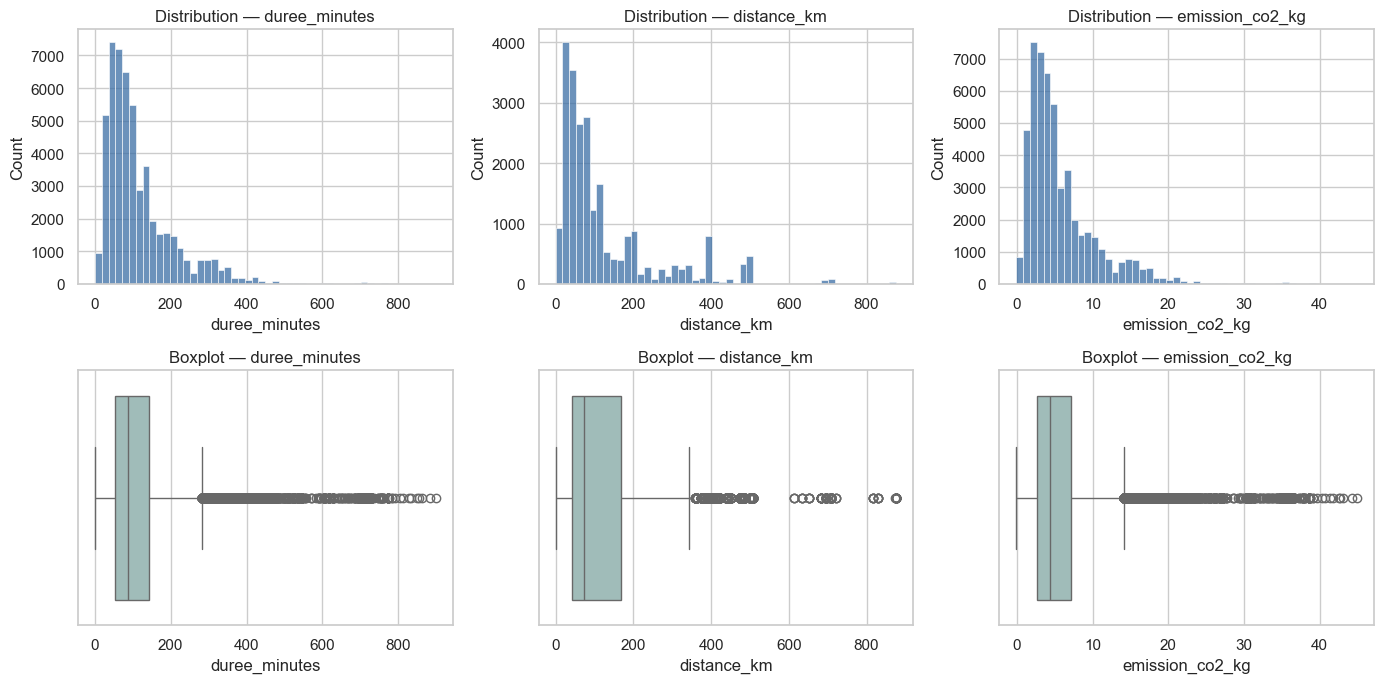

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, c in enumerate(num):
    sns.histplot(df[c].dropna(), bins=50, ax=axes[0, i], color="#3b6ea5")
    axes[0, i].set_title(f"Distribution — {c}")
    sns.boxplot(x=df[c].dropna(), ax=axes[1, i], color="#9bc1bc")
    axes[1, i].set_title(f"Boxplot — {c}")
plt.tight_layout(); plt.savefig(FIG/"01_distributions.png", dpi=110); plt.show()

**Lecture :** les distributions sont fortement asymétriques à droite — beaucoup de trajets
courts (régionaux), une longue traîne de trajets plus longs. À retenir pour le choix
des transformations à l'étape 3 (log, standardisation, traitement des outliers).

## 4. Analyse des variables catégorielles

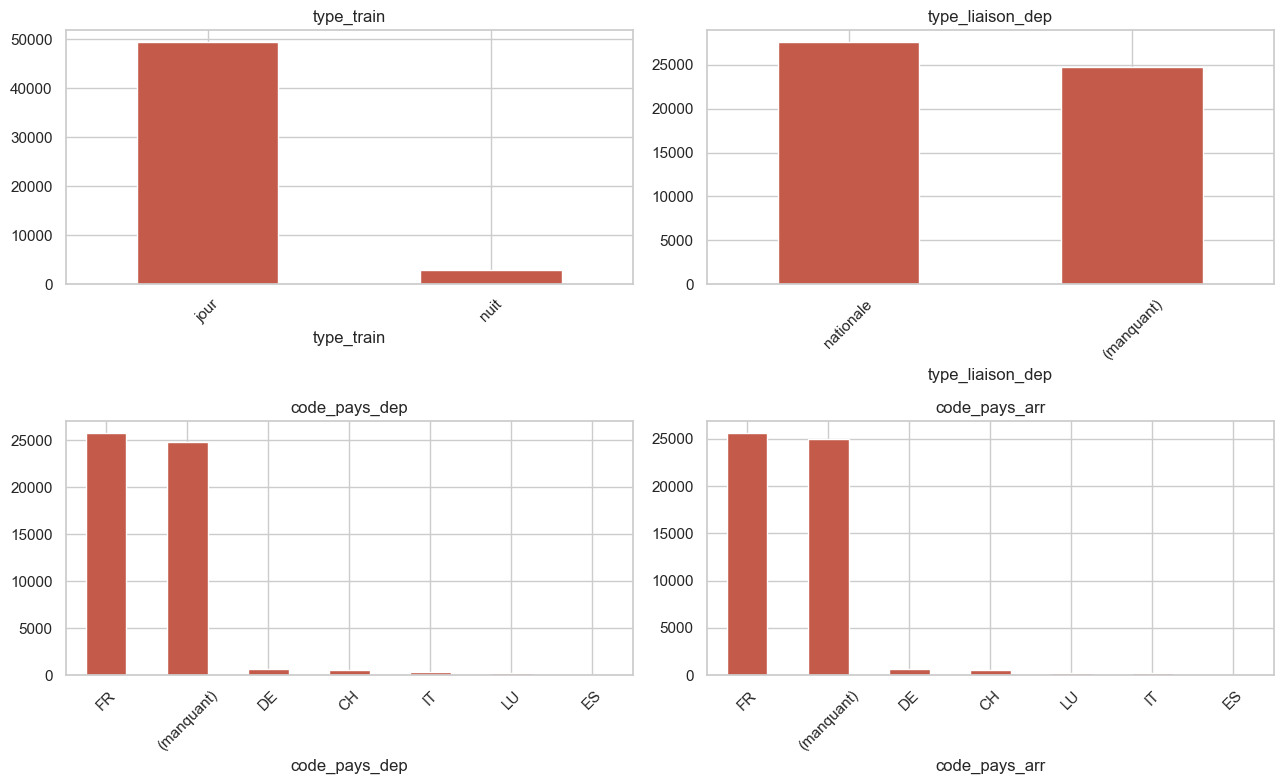

In [8]:
cat = ["type_train", "type_liaison_dep", "code_pays_dep", "code_pays_arr"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, c in zip(axes.ravel(), cat):
    df[c].fillna("(manquant)").value_counts().head(8).plot.bar(ax=ax, color="#c45b4a")
    ax.set_title(c); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig(FIG/"02_categorielles.png", dpi=110); plt.show()

In [9]:
# Paires de pays les plus frequentes
print("Top 10 paires de pays :")
print(df["paire_pays"].value_counts().head(10).to_string())
print(f"\n% FR-FR        : {(df['paire_pays']=='FR-FR').mean()*100:.1f}%")
inter = (df['code_pays_dep'] != df['code_pays_arr']) & df['code_pays_dep'].notna() & df['code_pays_arr'].notna()
print(f"% international (pays connus differents) : {inter.mean()*100:.1f}%")

Top 10 paires de pays :
paire_pays
FR-FR    22087
?-?      21105
FR-?      2953
?-FR      2822
?-CH       510
CH-?       500
FR-DE      374
DE-FR      367
IT-?       309
?-IT       236

% FR-FR        : 42.2%
% international (pays connus differents) : 2.6%


## 5. Analyse bivariée et corrélations

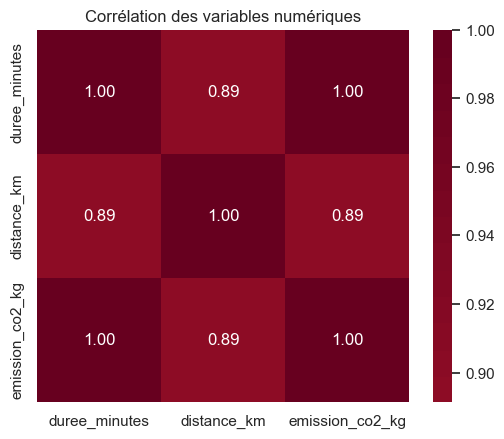

,duree_minutes,distance_km,emission_co2_kg
duree_minutes,1.00,0.89,1.00
distance_km,0.89,1.00,0.89
emission_co2_kg,1.00,0.89,1.00


In [10]:
corr = df[num].corr()
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True)
plt.title("Corrélation des variables numériques")
plt.tight_layout(); plt.savefig(FIG/"03_correlation.png", dpi=110); plt.show()
corr.round(2)

C:\Users\Handi\AppData\Local\Temp\ipykernel_33016\1886276887.py:8: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.savefig(FIG/"04_relations.png", dpi=110); plt.show()


C:\Users\Handi\.venvs\mspr-obrail\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


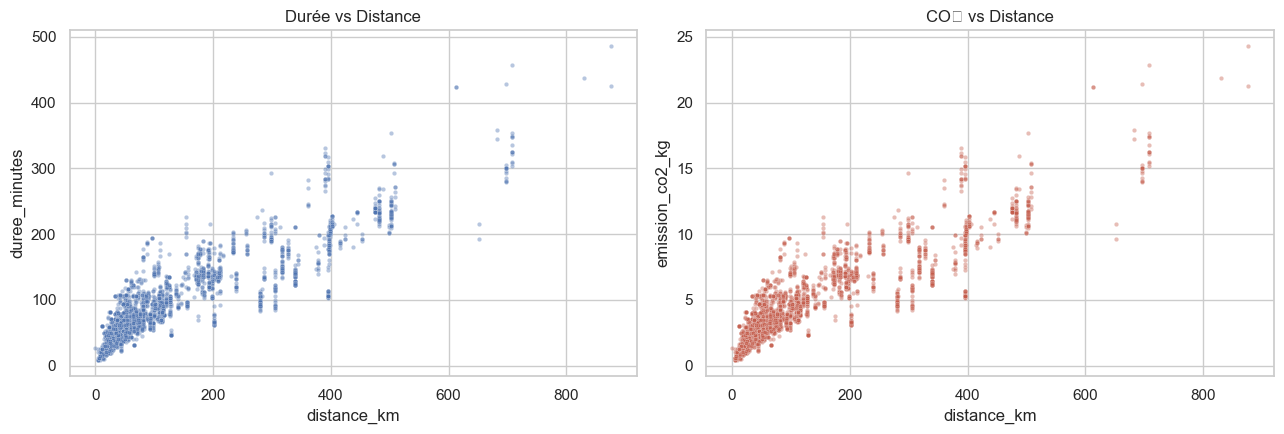

In [11]:
# Relation distance / duree / CO2
sub = df.dropna(subset=["distance_km"]).sample(min(4000, df["distance_km"].notna().sum()), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=sub, x="distance_km", y="duree_minutes", s=10, alpha=.4, ax=axes[0])
axes[0].set_title("Durée vs Distance")
sns.scatterplot(data=sub, x="distance_km", y="emission_co2_kg", s=10, alpha=.4, ax=axes[1], color="#c45b4a")
axes[1].set_title("CO₂ vs Distance")
plt.tight_layout(); plt.savefig(FIG/"04_relations.png", dpi=110); plt.show()

## 6. Vue au niveau liaison (origine → destination)

In [12]:
agg = (df.groupby(["nom_officiel_dep", "nom_officiel_arr"])
         .agg(nb_services=("id_trajet", "count"),
              duree_med=("duree_minutes", "median"),
              distance_km=("distance_km", "median"),
              co2_med=("emission_co2_kg", "median"))
         .reset_index()
         .sort_values("nb_services", ascending=False))
print(f"{len(agg):,} liaisons distinctes")
agg.head(10)

1,169 liaisons distinctes


,nom_officiel_dep,nom_officiel_arr,nb_services,duree_med,distance_km,co2_med
466,Le Mans,Paris Montparnasse Hall 1 - 2,262,140.0,183.02,7.00
753,Paris Gare du Nord,Amiens,217,90.0,112.41,4.50
244,Chartres,Paris Montparnasse Hall 1 - 2,202,75.0,75.57,3.75
780,Paris Montparnasse Hall 1 - 2,Brest,176,229.0,502.32,11.45
786,Paris Montparnasse Hall 1 - 2,Le Mans,176,140.0,183.02,7.00
158,Brest,Paris Montparnasse Hall 1 - 2,169,231.0,502.32,11.55
681,Nantes,Paris Montparnasse Hall 1 - 2,169,138.0,339.20,6.90
650,Nancy,Metz,153,53.0,46.66,2.65
781,Paris Montparnasse Hall 1 - 2,Chartres,151,77.0,75.57,3.85
746,Paris Est,Strasbourg,151,115.0,395.50,5.75


## 7. Cadrage métier : l'axe « substitution avion → train » est-il soutenable ?

La substitution avion → train n'a de sens qu'à partir d'une certaine distance
(~500–800 km, seuil au-delà duquel l'avion devient compétitif). Vérifions la part
de trajets réellement concernés.

Trajets >= 300 km :  2,852  ( 5.5%)
Trajets >= 500 km :    624  ( 1.2%)
Trajets >= 800 km :     41  ( 0.1%)


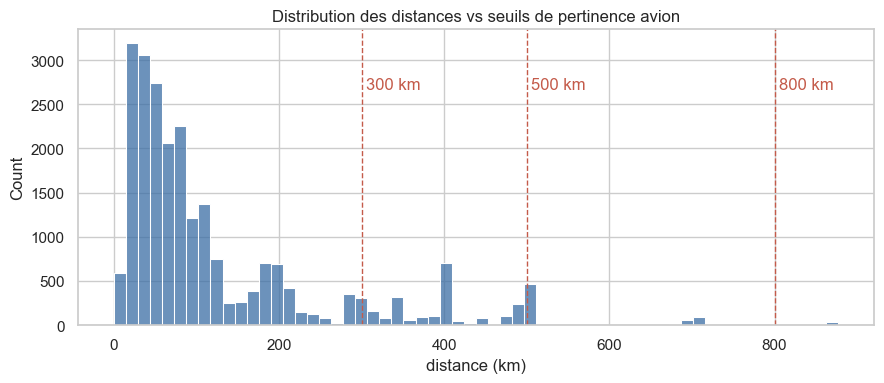

In [13]:
seuils = [300, 500, 800]
for s in seuils:
    part = (df["distance_km"] >= s).mean() * 100
    print(f"Trajets >= {s} km : {(df['distance_km']>=s).sum():>6,}  ({part:4.1f}%)")

plt.figure(figsize=(9, 4))
sns.histplot(df["distance_km"].dropna(), bins=60, color="#3b6ea5")
for s in seuils:
    plt.axvline(s, color="#c45b4a", ls="--", lw=1)
    plt.text(s+5, plt.ylim()[1]*0.8, f"{s} km", color="#c45b4a")
plt.title("Distribution des distances vs seuils de pertinence avion")
plt.xlabel("distance (km)")
plt.tight_layout(); plt.savefig(FIG/"05_pertinence_substitution.png", dpi=110); plt.show()

**Conclusion de cadrage :** la quasi-totalité des trajets sont courts et régionaux.
La part de trajets éligibles à une substitution avion est marginale (≈ 1 % au-delà de 500 km),
et le rapprochement opérateur/distance est partiellement manquant.

➡️ L'axe **« substitution avion → train » n'est pas soutenable** sur ce jeu de données.
Un axe **non supervisé de découverte de familles de dessertes** (clustering sur durée,
distance, CO₂, horaire) est nettement mieux aligné avec les données disponibles
et avec les enjeux ObRail (caractériser les dessertes, repérer les liaisons atypiques).

## 8. Tableau des variables retenues (livrable)

In [14]:
variables = pd.DataFrame([
    ["duree_minutes",   "numérique", "Durée du trajet (min)",            "Retenue",  "Variable de structure forte"],
    ["distance_km",     "numérique", "Distance vol d'oiseau (haversine)","Retenue*", "54% manquante -> à imputer/filtrer"],
    ["emission_co2_kg", "numérique", "Émissions CO₂ (kg)",               "Retenue",  "Corrigée des valeurs négatives"],
    ["heure_depart",    "temporelle","Heure de départ",                  "Dérivée",  "Sert à dériver jour/nuit"],
    ["type_train",      "catégorie", "Jour / Nuit (dérivé de l'heure)",  "Retenue",  "Feature engineering"],
    ["type_liaison_dep","catégorie", "Nationale / Inter. / Régionale",   "À part",   "Souvent manquante"],
    ["code_pays_dep",   "catégorie", "Pays de départ",                   "Retenue",  "À encoder"],
    ["code_pays_arr",   "catégorie", "Pays d'arrivée",                   "Retenue",  "À encoder"],
    ["operateur",       "catégorie", "Opérateur ferroviaire",            "Écartée",  "Jointure cassée (~100% nulle)"],
    ["nom_ligne",       "texte",     "Libellé de la ligne",              "Écartée",  "Identifiant, non prédictif"],
], columns=["variable","type","description","decision","justification"])
variables

,variable,type,description,decision,justification
0,duree_minutes,numérique,Durée du trajet (min),Retenue,Variable de structure forte
1,distance_km,numérique,Distance vol d'oiseau (haversine),Retenue*,54% manquante -> à imputer/filtrer
2,emission_co2_kg,numérique,Émissions CO₂ (kg),Retenue,Corrigée des valeurs négatives
3,heure_depart,temporelle,Heure de départ,Dérivée,Sert à dériver jour/nuit
4,type_train,catégorie,Jour / Nuit (dérivé de l'heure),Retenue,Feature engineering
5,type_liaison_dep,catégorie,Nationale / Inter. / Régionale,À part,Souvent manquante
6,code_pays_dep,catégorie,Pays de départ,Retenue,À encoder
7,code_pays_arr,catégorie,Pays d'arrivée,Retenue,À encoder
8,operateur,catégorie,Opérateur ferroviaire,Écartée,Jointure cassée (~100% nulle)
9,nom_ligne,texte,Libellé de la ligne,Écartée,"Identifiant, non prédictif"


## 9. Synthèse

- **Volumétrie** : ~52 000 services horaires pour ~3 800 liaisons distinctes (grain = service).
- **Profil** : réseau majoritairement régional français, trajets courts.
- **Qualité** : distance manquante à ~55 %, opérateur inexploitable, quelques CO₂ négatifs / durées nulles à nettoyer.
- **Décision d'axe** : pivot recommandé vers un **clustering de dessertes** (non supervisé),
  cohérent avec les données et avec l'esprit du cas d'usage.

**Étape suivante (étape 3 — préparation) :** nettoyage des aberrants, traitement des manquants,
agrégation au niveau liaison, encodage des catégorielles, normalisation, puis construction
des features pour la modélisation.